Question 1.1
Write a function that reads every speech file into a single frame-level table, with one row per frame: the identifier of the video, the fields of the file name that are needed, frame, timestamp, confidence and the 136 coordinates. Report its dimensions, and mark the rows of the four test actors. Reading only the required columns, and saving the table once in a binary format such as Parquet, avoids reading the CSV files again in every session.


In [ ]:
import os 
import pandas as pd
from pathlib import Path
import re

path = "../data"
DATA = Path(path)
useCols = ["frame","timestamp","confidence"]

for i in range(0,68):
    useCols.append(f"x_{i}")
    useCols.append(f"y_{i}")

testIndex = []
testActors = ["01","17","16","24"]

df = pd.DataFrame()
for root, dirs, files in os.walk(path):
    for n in files:
        p = re.split(r'[-.\s]+',n)
        
        if(p[1]) == "02" :
            continue
        if p[6] in testActors:
            testIndex.append(n)
        csv = pd.read_csv(DATA / n,usecols=useCols)
        csv.insert(1, "video", n)
        df = pd.concat([df,csv])

df.to_parquet("df.parquet.gzip", compression="gzip")
pd.read_parquet("df.parquet.gzip")       
        


Question 1.2
Build a video-level table of the development actors, with one row per video: actor, sex, emotion, intensity, statement, repetition and number of frames. Report the number of videos per emotion and per intensity, and the distribution of the number of frames per emotion.


In [52]:
import os 
import pandas as pd
from pathlib import Path
import re

path = "../data"
DATA = Path(path)


df = []
testActors = ["01","17","16","24"]
emotionLabels = ["Neutral", "Calm", "Happy", "Sad", "Angry", "Fearful", "Disgust", "Surprised"]
intensityLabels = ["Normal", "Strong"]
statementLabels = ["Kids are talking by the door", "Dogs are sitting by the door"]
repetitionLabels = ["First", "Second"]

for root, dirs, files in os.walk(path):
    for n in files:
        p = re.split(r'[-.\s]+',n)
        
        if(p[1]) == "02" :
            continue

        if p[6] in testActors : 
            continue
        
        csv = pd.read_csv(DATA / n,usecols=useCols)
        sex = 'F' if int(p[6])%2 == 0 else 'M'

        emotion = emotionLabels[int(p[2]) - 1]
        intensity = intensityLabels[int(p[3]) - 1]
        statement = statementLabels[int(p[4]) - 1]
        repetition = repetitionLabels[int(p[5]) - 1]

        video = {"actor": p[6], "sex": sex, "emotion": emotion, "intensity" : intensity, "statement": statement, "repetition": repetition, "number of frames" : len(csv)}
        df.append(video)

df = pd.DataFrame(df)
#print(df)
#Reports 
print(df["emotion"].value_counts())
print(df["intensity"].value_counts())
print(df.groupby("emotion")["number of frames"].describe())
        


emotion
Happy        160
Disgust      160
Sad          160
Angry        160
Surprised    160
Fearful      160
Calm         160
Neutral       80
Name: count, dtype: int64
intensity
Normal    640
Strong    560
Name: count, dtype: int64
           count       mean        std   min    25%    50%     75%    max
emotion                                                                  
Angry      160.0  115.28125   9.355436  97.0  108.0  114.0  122.00  143.0
Calm       160.0  113.56875  10.603561  88.0  107.0  112.0  120.00  143.0
Disgust    160.0  117.13750  11.505256  94.0  110.0  116.0  123.00  157.0
Fearful    160.0  105.56875   8.225304  92.0   99.0  105.0  110.25  131.0
Happy      160.0  108.30625   8.083679  93.0  103.0  107.0  113.00  132.0
Neutral     80.0  104.33750   6.314427  92.0   99.0  105.0  108.00  119.0
Sad        160.0  109.95625   8.676830  93.0  104.0  109.0  114.25  142.0
Surprised  160.0  104.11250   7.556069  89.0   98.0  104.5  109.00  138.0


Question 1.3
What does one row of the table of 1.1 represent, and one row of the table of 1.2? Which column identifies groups of rows that are not independent of one another, and why are they not independent?


In 1.1, each row represents a single video frame. In 1.2, each row represents an entire video. The "actor" column indentifies the groups of rows are not independent; since consecutive frames from the same video are nearly identical—given the rate of 30 frames per second—they share information. Furthermore, videos featuring the same actor share facial characteristics, meaning a given row contains information related to the others.


Question 1.4
Is the duration of a video related to the emotion portrayed? Would its use as a feature be legitimate in an application that classifies a new recording? Justify.


Video duration is related to emotion, though the correlation is weak. Emotions such as Disgust and Angry tend to have longer durations—117 and 115 frames, respectively. Emotions like Surprised and Fearful tend to have shorter durations—104 and 105 frames, respectively. However, given that the standard deviation ranges from 7 to 11 frames, there is an overlap between intervals; this leads to the conclusion that classifying an emotion based solely on video duration is not feasible.
Using emotion as a feature to classify a new video would not be valid. Since the model aims to classify emotions based on landmark positions, duration is unrelated to these features. Furthermore, in a real-world application, video duration depends on the person recording and the time taken to capture the footage; thus, this duration does not assist in identifying the emotion.

emotion     mean        diff(Neutral)       STD Dev
Disgust     117         13                  11
Angry       115         11                  9
Calm        113         9                   10
Sad         109         5                   8
Happy       108         4                   8
Fearful     105         1                   8
Surprised   104         0                   7

Question 1.5
Write a function that draws the 68 landmarks of one frame, joining the points of each facial region as in Figure 2, and a second function that overlays all the frames of one video. For one actor and one statement, compare the neutral video with a video of another emotion at strong intensity.

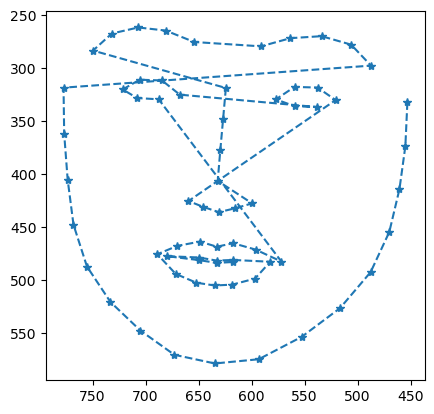

In [82]:
import matplotlib.pyplot as plt
import numpy as np
#ler os landmarks(passar a função)
frame = 0

colsX = [f"x_{k}" for k in range(68)]
colsY = [f"y_{k}" for k in range(68)]

landmarks = pd.read_parquet("df.parquet.gzip",columns= colsX + colsY)
landmarkIndiv = landmarks.iloc[frame]

pointsX = landmarkIndiv[colsX].to_numpy()
pointsY = landmarkIndiv[colsY].to_numpy()
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.gca().set_aspect("equal")
plt.plot(pointsX,pointsY,"*",linestyle="--")
